In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

/content/drive/MyDrive/Generalizable-DDA-RL


### ***Importing Packages***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.player import SimulatedPlayer

print("Imports Successful!")

Imports Successful!


### ***Creating Player Skill Estimator***

In [13]:
%%writefile src/player_estimator.py

import numpy as np


class PlayerSkillEstimator:
    """
    Estimates hidden player skill from observable gameplay telemetry.

    The estimator does NOT access true player skill.

    Inputs:
    - success
    - completion_time
    - error_rate

    Outputs:
    - estimated_skill
    - uncertainty

    Uncertainty is a heuristic confidence proxy based on:
    - recent estimation variability
    - number of observations
    """

    def __init__(
        self,
        window_size=20,
        smoothing=0.2
    ):

        self.window_size = window_size
        self.smoothing = smoothing

        self.reset()


    def reset(self):

        self.estimated_skill = 0.5

        self.observation_history = []

        self.estimate_history = []


    def _telemetry_to_skill(
        self,
        success,
        completion_time,
        error_rate
    ):

        success_signal = float(success)

        time_signal = 1.0 / (
            1.0 + completion_time
        )

        error_signal = (
            1.0 - error_rate
        )

        skill_signal = (
            0.50 * success_signal
            + 0.25 * time_signal
            + 0.25 * error_signal
        )

        return float(
            np.clip(
                skill_signal,
                0.0,
                1.0
            )
        )


    def update(
        self,
        success,
        completion_time,
        error_rate
    ):

        observation_skill = (
            self._telemetry_to_skill(
                success,
                completion_time,
                error_rate
            )
        )

        self.observation_history.append(
            observation_skill
        )

        if len(self.observation_history) > self.window_size:

            self.observation_history.pop(0)


        self.estimated_skill = (
            (1 - self.smoothing)
            * self.estimated_skill
            +
            self.smoothing
            * observation_skill
        )

        self.estimated_skill = float(
            np.clip(
                self.estimated_skill,
                0.0,
                1.0
            )
        )


        # Store smoothed estimates
        self.estimate_history.append(
            self.estimated_skill
        )

        if len(self.estimate_history) > self.window_size:

            self.estimate_history.pop(0)


        # -----------------------------
        # Improved uncertainty estimate
        # -----------------------------

        n = len(
            self.estimate_history
        )

        if n < 2:

            uncertainty = 0.20

        else:

            estimate_std = np.std(
                self.estimate_history
            )

            # Standard error decreases
            # as more observations arrive.
            uncertainty = (
                estimate_std
                /
                np.sqrt(n)
            )

            # Keep uncertainty within
            # a useful normalized range.
            uncertainty = float(
                np.clip(
                    uncertainty,
                    0.02,
                    0.25
                )
            )


        return {

            "estimated_skill":
                float(
                    self.estimated_skill
                ),

            "uncertainty":
                uncertainty,

            "observation_skill":
                float(
                    observation_skill
                )
        }

Overwriting src/player_estimator.py


In [14]:
import importlib
import src.player_estimator

importlib.reload(
    src.player_estimator
)

from src.player_estimator import PlayerSkillEstimator

print("Updated Estimator Loaded Successfully!")

Updated Estimator Loaded Successfully!


### ***Testing the Estimator***

In [15]:
from src.player_estimator import PlayerSkillEstimator


estimator = PlayerSkillEstimator(
    window_size=20,
    smoothing=0.2
)


result = estimator.update(
    success=1,
    completion_time=0.8,
    error_rate=0.1
)


print(result)

{'estimated_skill': 0.5727777777777778, 'uncertainty': 0.2, 'observation_skill': 0.8638888888888888}


### ***Test on Learning Player***

In [16]:
player = SimulatedPlayer(
    initial_skill=0.3,
    learning_rate=0.003,
    fatigue_rate=0.0,
    noise_std=0.05,
    seed=42
)


estimator = PlayerSkillEstimator(
    window_size=20,
    smoothing=0.2
)


player.reset()
estimator.reset()


true_skills = []
estimated_skills = []
uncertainties = []


difficulty = 0.5


for step in range(200):

    telemetry = player.play(
        difficulty=difficulty
    )

    estimate = estimator.update(
        success=telemetry["success"],
        completion_time=telemetry[
            "completion_time"
        ],
        error_rate=telemetry[
            "error_rate"
        ]
    )

    true_skills.append(
        telemetry["true_skill"]
    )

    estimated_skills.append(
        estimate["estimated_skill"]
    )

    uncertainties.append(
        estimate["uncertainty"]
    )


print("Simulation Complete :)")

Simulation Complete :)


### ***Plotting True Skill vs Estimating Skill***

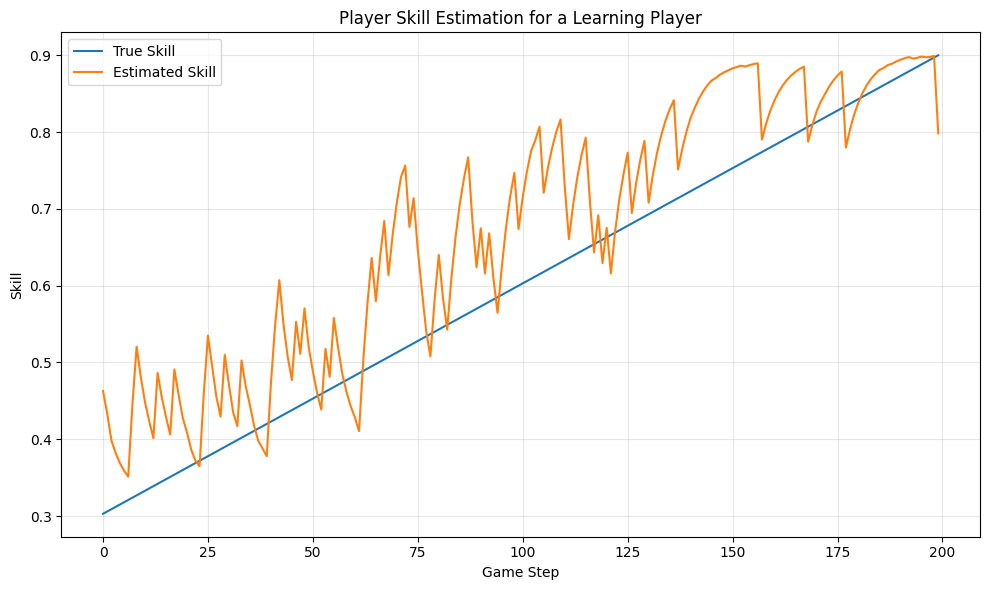

Figure Saved Successfully!


In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    true_skills,
    label="True Skill"
)

plt.plot(
    estimated_skills,
    label="Estimated Skill"
)

plt.xlabel("Game Step")
plt.ylabel("Skill")

plt.title(
    "Player Skill Estimation for a Learning Player"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "results/figures/"
    "true_vs_estimated_skill.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure Saved Successfully!")

### ***Combined Paper-Quality Figure***

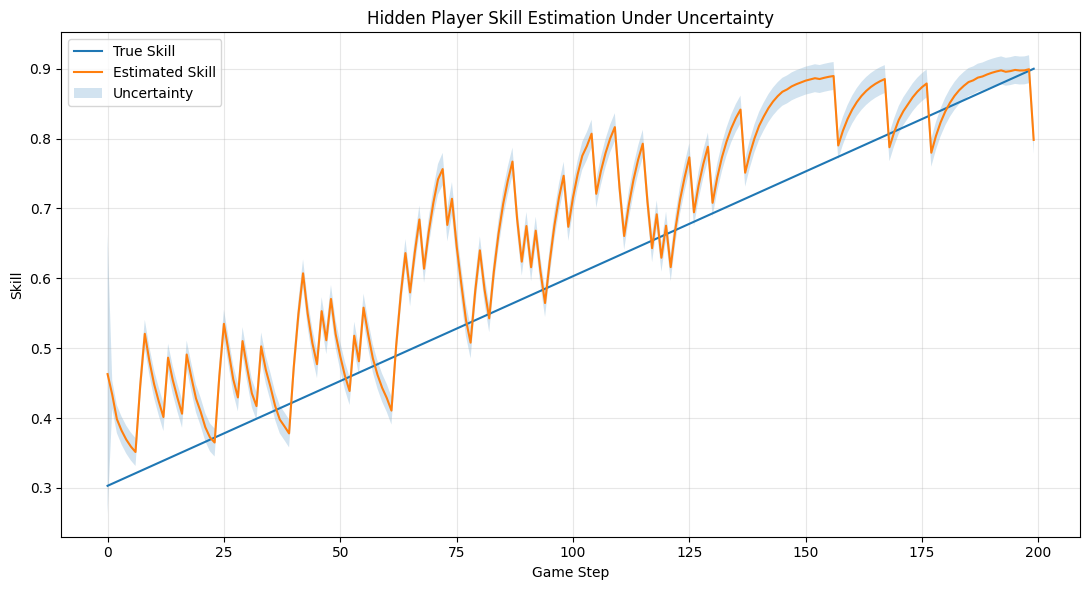

Combined Figure Saved Successfully!


In [18]:
plt.figure(figsize=(11, 6))

plt.plot(
    true_skills,
    label="True Skill"
)

plt.plot(
    estimated_skills,
    label="Estimated Skill"
)

lower_bound = (
    np.array(estimated_skills)
    -
    np.array(uncertainties)
)

upper_bound = (
    np.array(estimated_skills)
    +
    np.array(uncertainties)
)

lower_bound = np.clip(
    lower_bound,
    0,
    1
)

upper_bound = np.clip(
    upper_bound,
    0,
    1
)

plt.fill_between(
    range(len(estimated_skills)),
    lower_bound,
    upper_bound,
    alpha=0.2,
    label="Uncertainty"
)

plt.xlabel("Game Step")
plt.ylabel("Skill")

plt.title(
    "Hidden Player Skill Estimation Under Uncertainty"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "results/figures/"
    "skill_estimation_with_uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Combined Figure Saved Successfully!"
)

### ***Calculate Estimation Accuracy***

In [19]:
true_skills_array = np.array(
    true_skills
)

estimated_skills_array = np.array(
    estimated_skills
)


mae = np.mean(
    np.abs(
        true_skills_array
        -
        estimated_skills_array
    )
)


rmse = np.sqrt(
    np.mean(
        (
            true_skills_array
            -
            estimated_skills_array
        ) ** 2
    )
)


print(
    f"Mean Absolute Error (MAE): {mae:.4f}"
)

print(
    f"Root Mean Squared Error (RMSE): {rmse:.4f}"
)

Mean Absolute Error (MAE): 0.0773
Root Mean Squared Error (RMSE): 0.0942


In [12]:
!find src results/figures -type f | sort

results/figures/player_profiles.png
results/figures/skill_estimation_with_uncertainty.png
results/figures/true_vs_estimated_skill.png
src/__init__.py
src/player_estimator.py
src/player.py
src/__pycache__/__init__.cpython-313.pyc
src/__pycache__/player.cpython-313.pyc
src/__pycache__/player_estimator.cpython-313.pyc
